Question: how does the optimizer affect performance?

In [1]:
import os, shutil
from training import TrainingHistory, fit_model
from training import fit_model
# from training_data import TrainingData, Normalizer
import matplotlib.pyplot as plt

2023-10-26 11:10:31.714431: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-10-26 11:10:32.627780: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
save_path = "models/test_optimizers"
training_data_path = "training_data"

In [3]:
from training_data import load_training_data
import keras.optimizers
training_data = load_training_data(training_data_path)
levels = list(training_data.levels.keys())
optimizers = {
    'Adam': keras.optimizers.Adam(),
    'RMSprop': keras.optimizers.RMSprop(),
    'Nadam': keras.optimizers.Nadam(),
    'SGD+momentum': keras.optimizers.SGD(momentum=0.2),
}
save_paths = {opt:f"{save_path}/optimizer_{opt}" for opt in optimizers}

2023-10-26 11:10:36.738422: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1639] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22246 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:65:00.0, compute capability: 8.6


In [4]:
if os.path.exists(save_path):
    shutil.rmtree(save_path)
training_level = 'd0.40'
train_depth = 0.9
for optname, optimizer in optimizers.items():
    print(f"=== training with optimizer {optname} ===")
    fit_model(
        training_data=training_data_path,
        training_level=training_level,
        train_depth=train_depth,
        optimizer=optimizer,
        save_path=save_paths[optname],
        model_type='ResNet101V2',
    )

=== training with optimizer Adam ===
GPUS: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')] False
Loaded 99500 training examples and 3000 validation examples
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet101v2 (Functional)    (None, 16, 16, 2048)      42626560  
                                                                 
 global_average_pooling2d (  (None, 2048)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 3)                 6147      
                                                                 
Total params: 42632707 (162.63 MB)
Trainable params: 6147 (24.01 KB)
Non-trainable params: 42626560 (162.61 MB)
_________________________________________________________________
None
Epoch 1/10


2023-10-26 11:11:09.070205: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8600
2023-10-26 11:11:10.401789: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:606] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2023-10-26 11:11:11.498656: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x1e532220 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2023-10-26 11:11:11.498704: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 3090, Compute Capability 8.6
2023-10-26 11:11:11.515293: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:255] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2023-10-26 11:11:11.719439: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the proce


Batch 0


2023-10-26 11:11:23.797464: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 9000000000 exceeds 10% of free system memory.
2023-10-26 11:11:29.796991: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 9000000000 exceeds 10% of free system memory.


saving weigts to models/test_optimizers/optimizer_Adam/fit_weights
 100/1554 [>.............................] - ETA: 9:16 - loss: 0.0737
Batch 100


...

 100/1554 [>.............................] - ETA: 9:10 - loss: 0.0671
Batch 100
    Training MSE (xyz, xy, z): 0.10337031205803977 0.07571603232166786 0.15867887153078364  Slopes: [-0.017406484658748445, -0.015120212162296103, -0.01820781122981647]
    Validation d0.00  MSE (xyz, xy, z): 0.112 0.0542 0.228  Slopes: -0.016 -0.00956 -0.0169
    Validation d0.20  MSE (xyz, xy, z): 0.0972 0.0591 0.174  Slopes: -0.0171 -0.0129 -0.0179
    Validation d0.40  MSE (xyz, xy, z): 0.108 0.0939 0.136  Slopes: -0.0171 -0.0132 -0.0184
    Validation d0.60  MSE (xyz, xy, z): 0.218 0.22 0.215  Slopes: -0.0155 -0.0127 -0.0175
    Validation d0.80  MSE (xyz, xy, z): 0.578 0.631 0.471  Slopes: -0.0107 -0.00834 -0.014
    Validation d1.00  MSE (xyz, xy, z): 0.952 1.13 0.605  Slopes: -0.00865 -0.00391 -0.0146
 200/1554 [==>...........................] - ETA: 12:52 - loss: 0.0524
Batch 200
    Training MSE (xyz, xy, z): 0.04713279376007388 0.055886047190264306 0.029626286899693034  Slopes: [-0.01319392014201

INFO:tensorflow:Assets written to: models/test_optimizers/optimizer_Nadam/fit_model/assets


=== training with optimizer SGD+momentum ===
GPUS: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')] False
Loaded 99500 training examples and 3000 validation examples
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet101v2 (Functional)    (None, 16, 16, 2048)      42626560  
                                                                 
 global_average_pooling2d (  (None, 2048)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 3)                 6147      
                                                                 
Total params: 42632707 (162.63 MB)
Trainable params: 6147 (24.01 KB)
Non-trainable params: 42626560 (162.61 MB)
_________________________________________________________________
None
Epoch 1/10

Batch 0

 100/1554 [>.............................] - ETA: 9:09 - loss: 0.1144
Batch 100
    Training MSE (xyz, xy, z): 0.13014218978297354 0.15823535543894057 0.07395585847103942  Slopes: [-0.009520886259093678, -0.0072748227062992285, -0.014030013482410404]
    Validation d0.00  MSE (xyz, xy, z): 0.0747 0.1 0.0243  Slopes: -0.0116 -0.00123 -0.0185
    Validation d0.20  MSE (xyz, xy, z): 0.107 0.132 0.0557  Slopes: -0.00996 -0.00428 -0.0163
    Validation d0.40  MSE (xyz, xy, z): 0.114 0.137 0.0686  Slopes: -0.0105 -0.00692 -0.0154
    Validation d0.60  MSE (xyz, xy, z): 0.231 0.277 0.14  Slopes: -0.00754 -0.00536 -0.0122
    Validation d0.80  MSE (xyz, xy, z): 0.584 0.708 0.336  Slopes: -0.00138 0.000273 -0.00615
    Validation d1.00  MSE (xyz, xy, z): 0.981 1.2 0.543  Slopes: -4.5e-06 0.000341 -0.0014
 200/1554 [==>...........................] - ETA: 12:59 - loss: 0.0894
Batch 200
    Training MSE (xyz, xy, z): 0.08257690874295444 0.1071475229794768 0.03343568026990972  Slopes: [-0.007354397

INFO:tensorflow:Assets written to: models/test_optimizers/optimizer_SGD+momentum/fit_model/assets


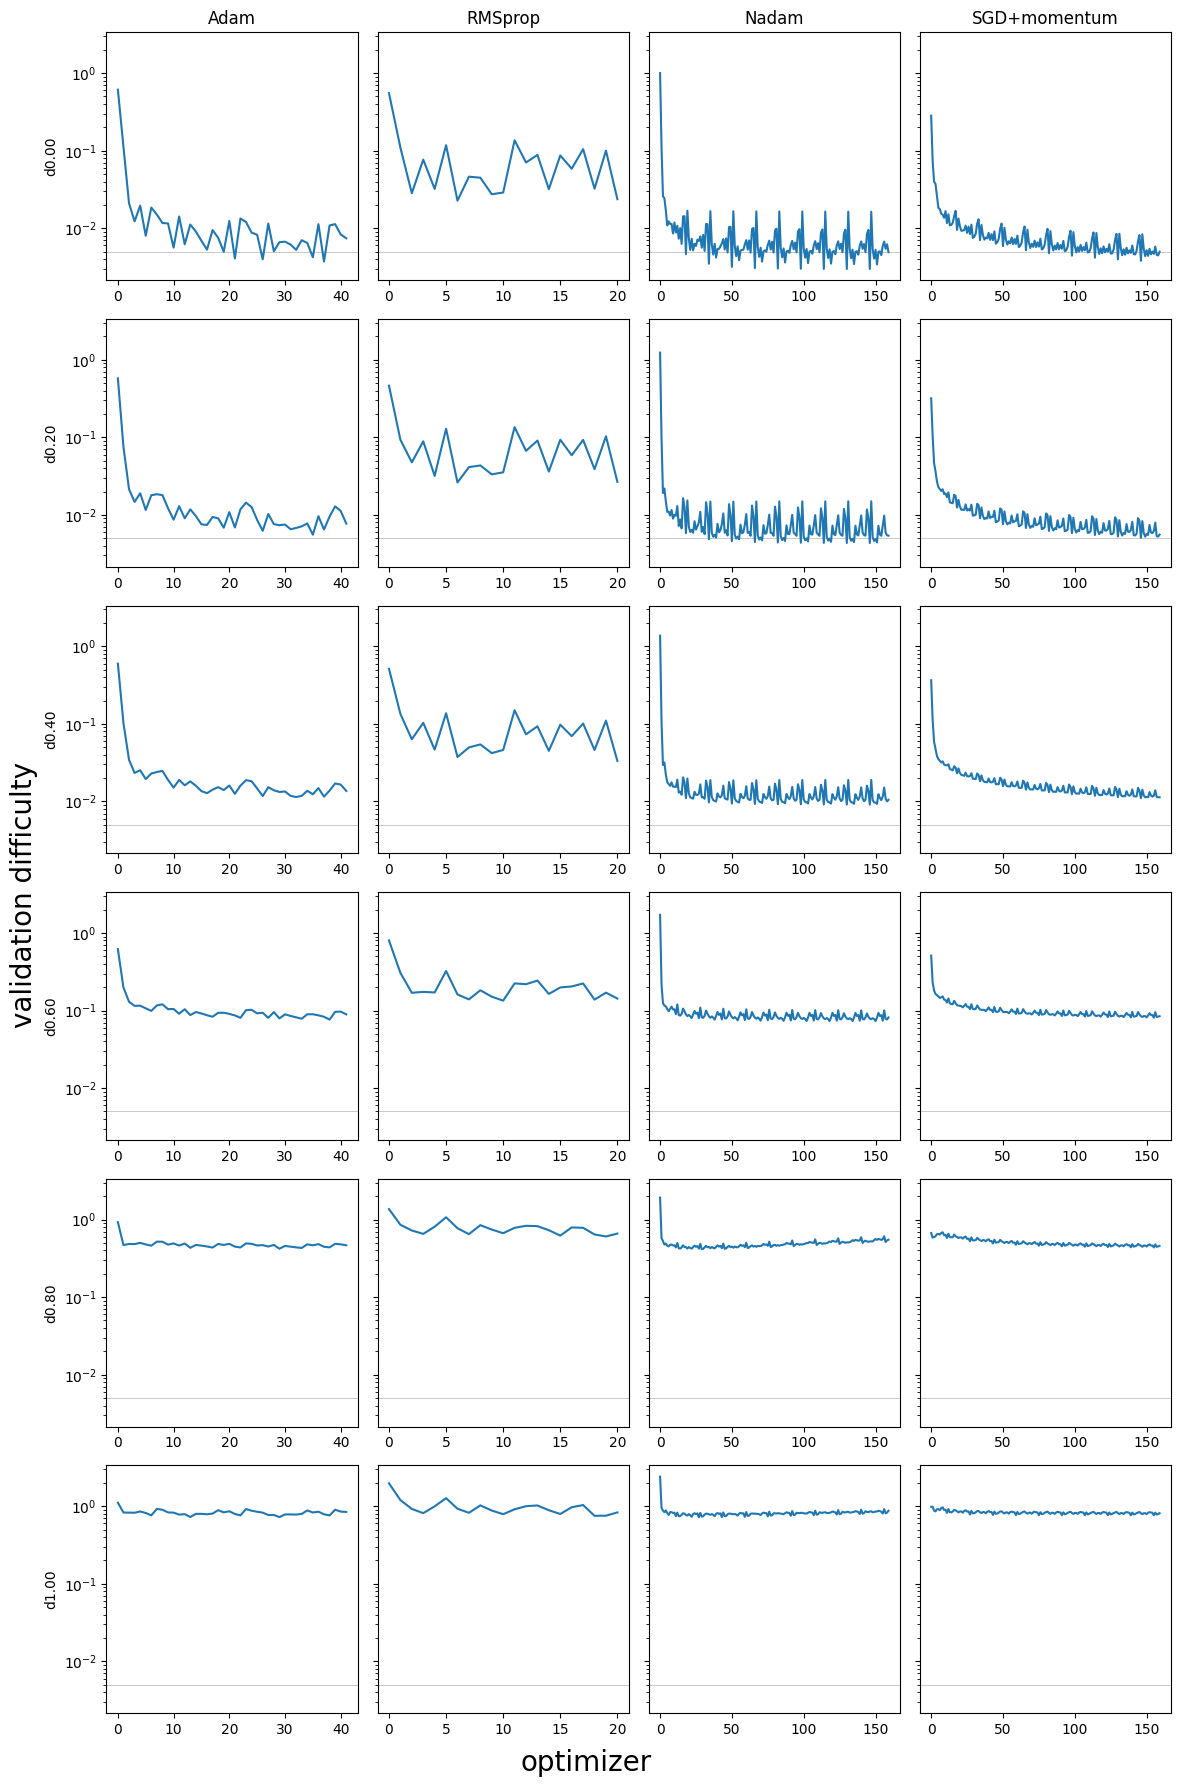

In [5]:
fig, ax = plt.subplots(len(levels), len(optimizers), figsize=(len(optimizers)*3, len(levels)*3), sharey=True)
fig.supylabel('validation difficulty', fontsize=20)
fig.supxlabel('optimizer', fontsize=20)
for i, level in enumerate(levels):
    ax[i, 0].set_ylabel(level)
for i,optname in enumerate(optimizers):
    history = TrainingHistory(f'{save_paths[optname]}/training_history.json')
    history.plot_loss(metrics=['mse'], ax=ax[:, i:i+1])
    ax[0, i].set_title(optname)
fig.tight_layout()

In [6]:
from model import PipetteDetectionModel
opt = 'Nadam'
model = PipetteDetectionModel(load_model=save_paths[opt])

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet101v2 (Functional)    (None, 16, 16, 2048)      42626560  
                                                                 
 global_average_pooling2d (  (None, 2048)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 3)                 6147      
                                                                 
Total params: 42632707 (162.63 MB)
Trainable params: 6147 (24.01 KB)
Non-trainable params: 42626560 (162.61 MB)
_________________________________________________________________
None


1/1 [==============================] - 0s 60ms/step


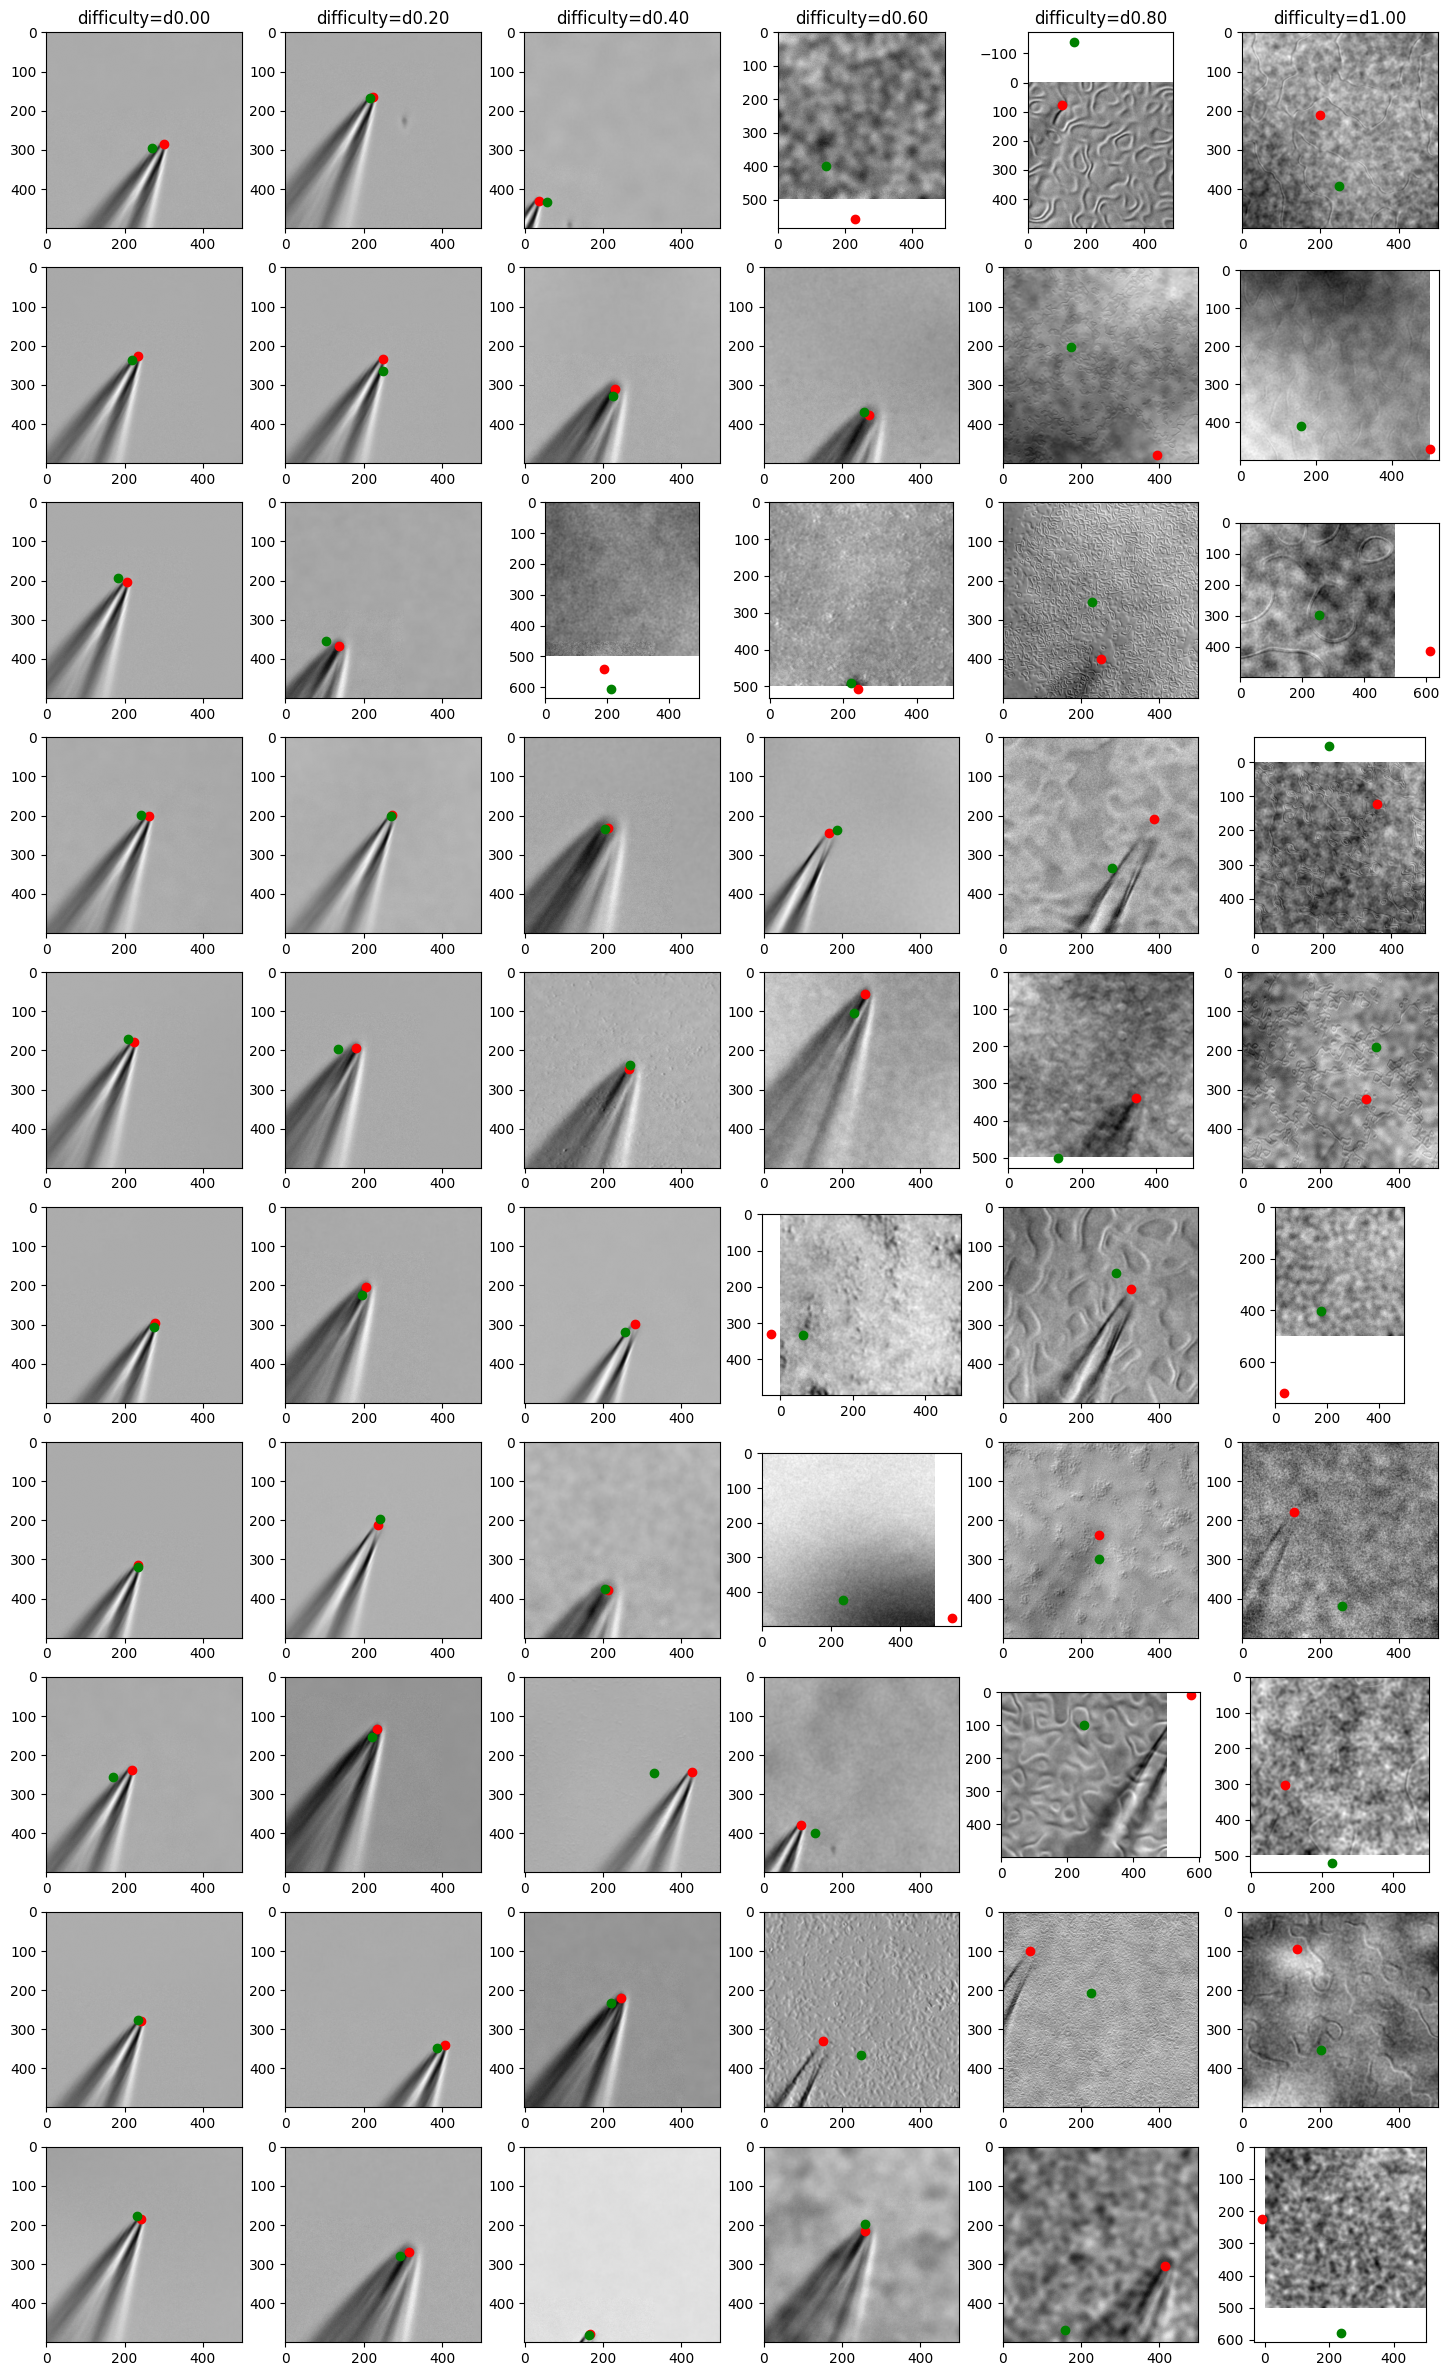

In [7]:
shape = (10, len(levels))
fig, ax = plt.subplots(shape[0], shape[1], figsize=(shape[1]*3, shape[0]*3))

for j, level in enumerate(levels):
    ax[0,j].set_title(f"difficulty={level}")
    image, pip_pos = training_data.levels[level][:shape[0]].get_arrays()
    pip_pos = training_data.output_norm.denormalize(pip_pos)
    pred = training_data.output_norm.denormalize(model.model.predict(image))
    for i in range(shape[0]):
        ax[i,j].imshow(image[i], cmap='gray')
        ax[i,j].scatter(pip_pos[i, 2], pip_pos[i, 1], color='red')
        ax[i,j].scatter(pred[i, 2], pred[i, 1], color='green')
        